In [1]:
#import libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Analysis objectives
1. Are the classes balaced? (Class balancing)
2. Are there correlations between the different factors and dianetes occurence. (correlation)
3. How does diabetes prevalence vary across age groups? (Binning)
4. How does smoking history affect diabetes prevalence? (deep analytics)
5. Hypotheses:
    - Do diabetic patients have significantly higher HbA1c levels?
    - Do diabetic patients have significantly higher blood glucose levels?
    - Which variable best separates diabetic and non-diabetic patients?
6. Is there an interaction between smoking and age? (factor analysis)
7. Identify hidden patient segments exhibiting different diabetes risk profiles through unsupervised learning.
8. Establish clinical risk thresholds for HbA1c and blood glucose levels that can support early diabetes screening

# Assumptions
 - assuming no duplicates

In [2]:
df=pd.read_csv('diabetes_prediction_dataset.csv')
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [4]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [5]:
#quick pre-processing
df.duplicated().sum()

np.int64(3854)

/var/folders/5g/7m5tb_kn729bgtcb25k58dlc0000gn/T/ipykernel_80342/3166286014.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diabetes',data=df,palette='Set2')


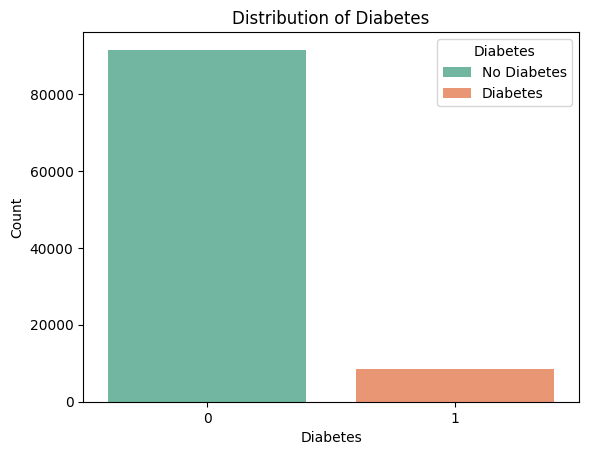

In [6]:
#visualise number of people with diabetes and without diabetes
sns.countplot(x='diabetes',data=df,palette='Set2')
plt.legend(title='Diabetes',labels=['No Diabetes','Diabetes'])
plt.title('Distribution of Diabetes')
plt.xlabel('Diabetes')
plt.ylabel('Count')
plt.show()

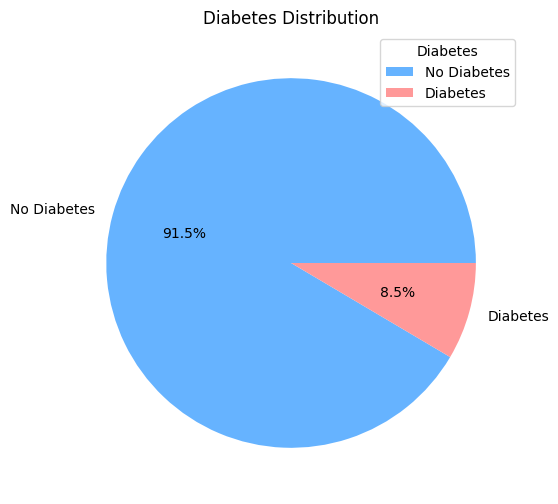

In [7]:
#pie chart for diabetes distribution
diabetes_counts=df['diabetes'].value_counts()
labels=['No Diabetes','Diabetes']
plt.figure(figsize=(6,6))
plt.pie(diabetes_counts,labels=labels,autopct='%1.1f%%',colors=['#66b3ff','#ff9999'])
plt.title('Diabetes Distribution')
plt.legend(title='Diabetes',labels=labels)
plt.show()

There is a much higher percentage of patients without hearts dsease as opposed to those with heart diseases. Classes are inbalanced.

In [8]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [9]:
Y=df['diabetes']
X=df.drop('diabetes',axis=1)

X.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
0,Female,80.0,0,1,never,25.19,6.6,140
1,Female,54.0,0,0,No Info,27.32,6.6,80
2,Male,28.0,0,0,never,27.32,5.7,158
3,Female,36.0,0,0,current,23.45,5.0,155
4,Male,76.0,1,1,current,20.14,4.8,155


In [10]:
Y.head()

0    0
1    0
2    0
3    0
4    0
Name: diabetes, dtype: int64

In [11]:
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

undersampler = RandomUnderSampler(random_state=0)

X_resampled, Y_resampled = undersampler.fit_resample(X, Y)
# print(sorted(Counter(Y_resampled).items()))

X_resampled

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
67423,Female,49.00,0,0,current,24.36,6.5,200
95697,Male,1.64,0,0,No Info,18.40,5.0,100
313,Male,6.00,0,0,No Info,27.32,6.2,155
93199,Female,14.00,0,0,No Info,21.37,6.2,145
49914,Female,40.00,0,0,never,27.32,6.5,160
...,...,...,...,...,...,...,...,...
99935,Female,65.00,1,1,never,33.55,8.2,140
99938,Male,55.00,0,1,former,30.42,6.2,300
99957,Female,61.00,0,0,No Info,34.45,6.5,280
99962,Female,58.00,1,0,never,38.31,7.0,200


In [12]:
Y_resampled

67423    0
95697    0
313      0
93199    0
49914    0
        ..
99935    1
99938    1
99957    1
99962    1
99979    1
Name: diabetes, Length: 17000, dtype: int64

In [13]:
df2=pd.concat([X_resampled, Y_resampled], axis=1)
df2

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
67423,Female,49.00,0,0,current,24.36,6.5,200,0
95697,Male,1.64,0,0,No Info,18.40,5.0,100,0
313,Male,6.00,0,0,No Info,27.32,6.2,155,0
93199,Female,14.00,0,0,No Info,21.37,6.2,145,0
49914,Female,40.00,0,0,never,27.32,6.5,160,0
...,...,...,...,...,...,...,...,...,...
99935,Female,65.00,1,1,never,33.55,8.2,140,1
99938,Male,55.00,0,1,former,30.42,6.2,300,1
99957,Female,61.00,0,0,No Info,34.45,6.5,280,1
99962,Female,58.00,1,0,never,38.31,7.0,200,1


/var/folders/5g/7m5tb_kn729bgtcb25k58dlc0000gn/T/ipykernel_80342/1878784008.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diabetes',data=df2,palette='Set2')


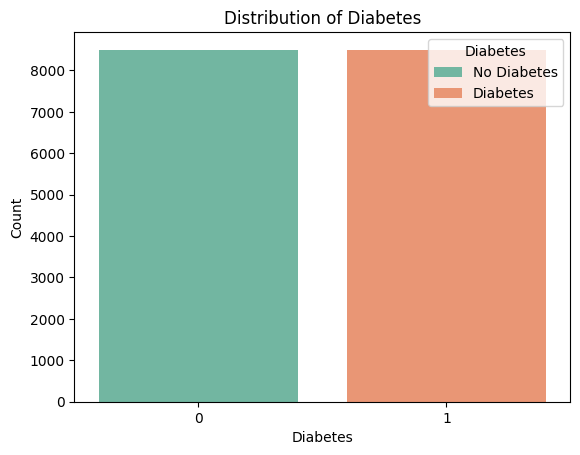

In [14]:
#visualise number of people with diabetes and without diabetes
sns.countplot(x='diabetes',data=df2,palette='Set2')
plt.legend(title='Diabetes',labels=['No Diabetes','Diabetes'])
plt.title('Distribution of Diabetes')
plt.xlabel('Diabetes')
plt.ylabel('Count')
plt.show()

Hence classes balanced bia random undersampling

In [15]:
#filter
df3=df2.query("gender not in ['Other']")
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16999 entries, 67423 to 99979
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               16999 non-null  object 
 1   age                  16999 non-null  float64
 2   hypertension         16999 non-null  int64  
 3   heart_disease        16999 non-null  int64  
 4   smoking_history      16999 non-null  object 
 5   bmi                  16999 non-null  float64
 6   HbA1c_level          16999 non-null  float64
 7   blood_glucose_level  16999 non-null  int64  
 8   diabetes             16999 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 1.3+ MB


In [16]:
df3['gender'].value_counts()

gender
Female    9490
Male      7509
Name: count, dtype: int64

In [17]:
gender_map={
    'Male':0,
    'Female':1
}
# encode gender
df3['gender'].replace(gender_map,inplace=True)
df3.head()

/var/folders/5g/7m5tb_kn729bgtcb25k58dlc0000gn/T/ipykernel_80342/4069340982.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df3['gender'].replace(gender_map,inplace=True)
/var/folders/5g/7m5tb_kn729bgtcb25k58dlc0000gn/T/ipykernel_80342/4069340982.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
67423,1,49.00,0,0,current,24.36,6.5,200,0
95697,0,1.64,0,0,No Info,18.40,5.0,100,0
313,0,6.00,0,0,No Info,27.32,6.2,155,0
93199,1,14.00,0,0,No Info,21.37,6.2,145,0
49914,1,40.00,0,0,never,27.32,6.5,160,0


In [18]:
df3['smoking_history'].value_counts()

smoking_history
never          6306
No Info        4631
former         2289
current        1752
not current    1261
ever            760
Name: count, dtype: int64

In [19]:
smoking_map={
    'No Info': 0,
    'never': 1,
    'former': 2,
    'current': 3,
    'not current': 4,
    'ever': 5
}

df3['smoking_history'].replace(smoking_map,inplace=True)
df3.head()


/var/folders/5g/7m5tb_kn729bgtcb25k58dlc0000gn/T/ipykernel_80342/1441774607.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df3['smoking_history'].replace(smoking_map,inplace=True)
/var/folders/5g/7m5tb_kn729bgtcb25k58dlc0000gn/T/ipykernel_80342/1441774607.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcast

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
67423,1,49.00,0,0,3,24.36,6.5,200,0
95697,0,1.64,0,0,0,18.40,5.0,100,0
313,0,6.00,0,0,0,27.32,6.2,155,0
93199,1,14.00,0,0,0,21.37,6.2,145,0
49914,1,40.00,0,0,1,27.32,6.5,160,0


In [20]:
df3.corr()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
gender,1.000000,-0.003912,-0.014845,-0.093932,-0.029350,0.036049,-0.040234,-0.041227,-0.067352
age,-0.003912,1.000000,0.248894,0.254154,0.186545,0.264697,0.290749,0.265115,0.480993
hypertension,-0.014845,0.248894,1.000000,0.102614,0.075569,0.151385,0.171141,0.138780,0.265153
heart_disease,-0.093932,0.254154,0.102614,1.000000,0.081331,0.049195,0.129848,0.118403,0.214702
smoking_history,-0.029350,0.186545,0.075569,0.081331,1.000000,0.133606,0.102030,0.085705,0.166928
bmi,0.036049,0.264697,0.151385,0.049195,0.133606,1.000000,0.196355,0.184057,0.337450
HbA1c_level,-0.040234,0.290749,0.171141,0.129848,0.102030,0.196355,1.000000,0.319374,0.601539
blood_glucose_level,-0.041227,0.265115,0.138780,0.118403,0.085705,0.184057,0.319374,1.000000,0.537421
diabetes,-0.067352,0.480993,0.265153,0.214702,0.166928,0.337450,0.601539,0.537421,1.000000


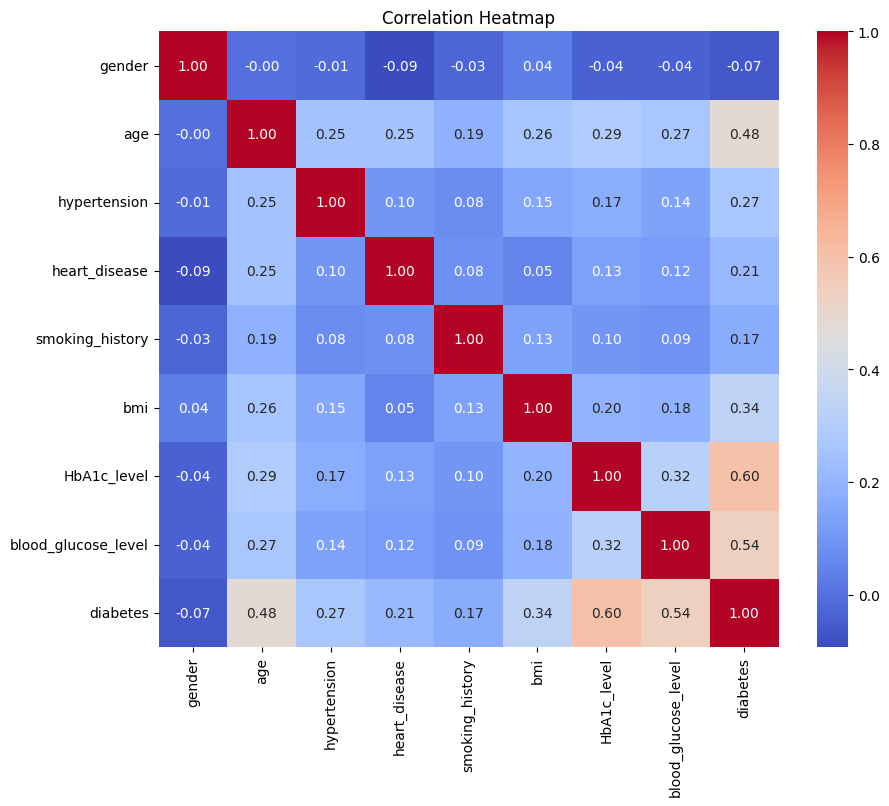

In [21]:
#correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df3.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


Diabetes is positively correlated with hab1c level, blood_glucose_level,age,hypertension and heart disease. For smoking, history, it has to be detailed further by looking at the distribution of smoking history among diabetes and non-diabetes patients.

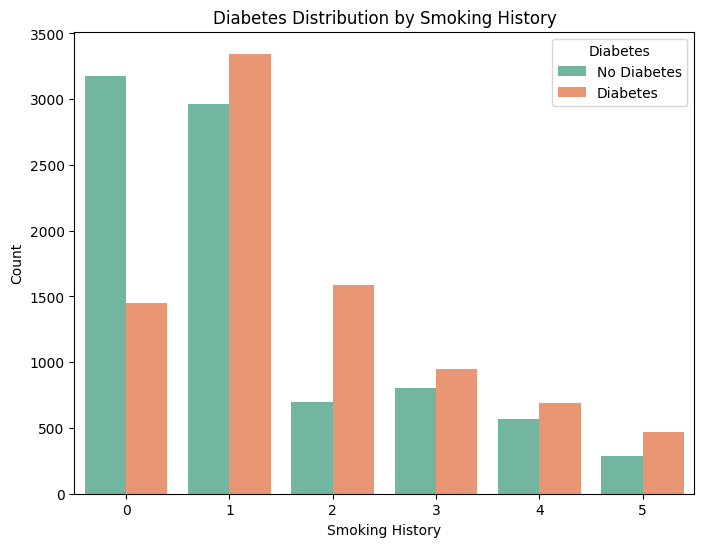

In [22]:
#analysiong case to case basis for smoking history and diabetes
plt.figure(figsize=(8,6))
sns.countplot(x='smoking_history', hue='diabetes', data=df3, palette='Set2')
plt.title('Diabetes Distribution by Smoking History')
plt.xlabel('Smoking History')
plt.ylabel('Count')
plt.legend(title='Diabetes', labels=['No Diabetes', 'Diabetes'])
plt.show()

Former smokers and non-current smokers have a higher prevalence of diabetes compared to never smokers, current smokers, and ever smokers. This suggests that smoking history may be associated with an increased risk of diabetes, particularly for those who have smoked in the past but are not currently smoking.

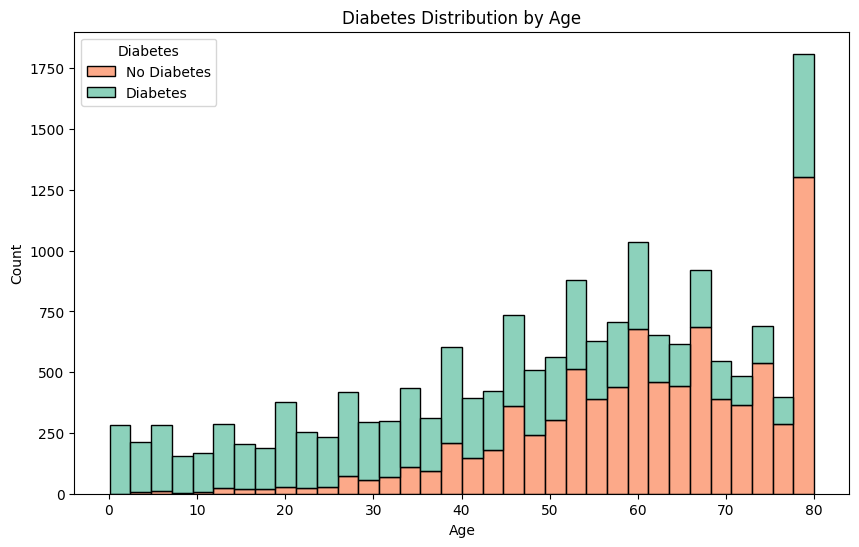

In [23]:
#diabetes distribution by age
plt.figure(figsize=(10,6))
sns.histplot(data=df3, x='age', hue='diabetes', multiple='stack', palette='Set2')
plt.title('Diabetes Distribution by Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Diabetes', labels=['No Diabetes', 'Diabetes'])
plt.show()

In [24]:
#binning age
bins=[0,30,50,70,100]

labels=['0-30','31-50','51-70','71+']
# labels=['0','1','2','3']

df3['age_group']=pd.cut(df3['age'], bins=bins, labels=labels) #binning
df3.head()

/var/folders/5g/7m5tb_kn729bgtcb25k58dlc0000gn/T/ipykernel_80342/438402720.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['age_group']=pd.cut(df3['age'], bins=bins, labels=labels) #binning


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,age_group
67423,1,49.00,0,0,3,24.36,6.5,200,0,31-50
95697,0,1.64,0,0,0,18.40,5.0,100,0,0-30
313,0,6.00,0,0,0,27.32,6.2,155,0,0-30
93199,1,14.00,0,0,0,21.37,6.2,145,0,0-30
49914,1,40.00,0,0,1,27.32,6.5,160,0,31-50


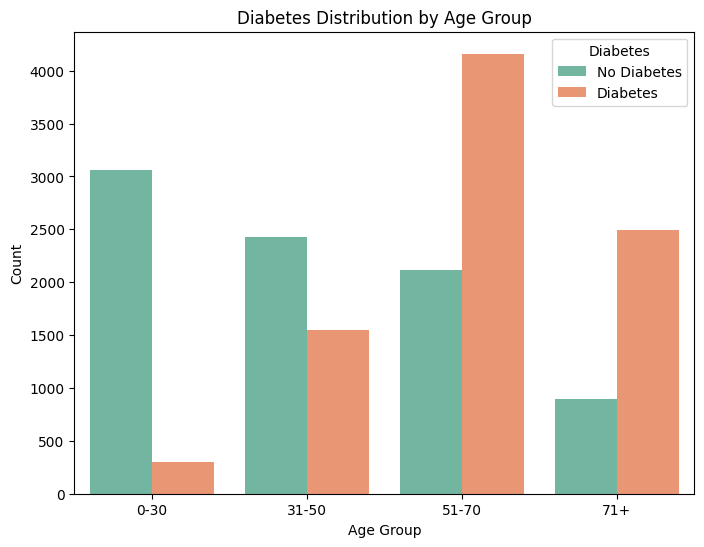

In [25]:
#plot age group vs diabetes
plt.figure(figsize=(8,6))
sns.countplot(x='age_group', hue='diabetes', data=df3, palette='Set2')
plt.title('Diabetes Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='Diabetes', labels=['No Diabetes', 'Diabetes'])
plt.show()

As from 51, someone is more prone to diabetes

diabetes
0    5.387916
1    6.934953
Name: HbA1c_level, dtype: float64
diabetes
0    132.840805
1    194.094706
Name: blood_glucose_level, dtype: float64


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

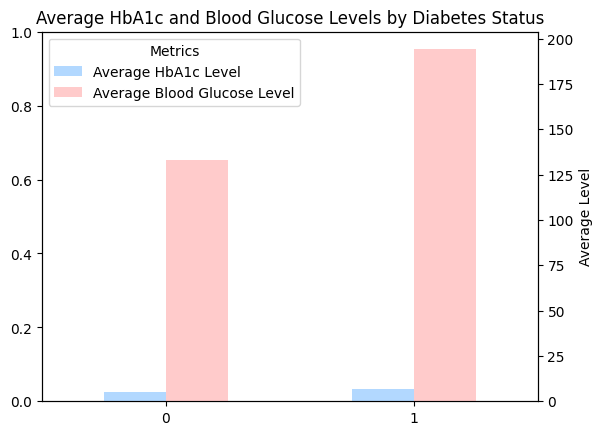

In [26]:
#multiple bar plot for hba1c and blood glucose for diabetest and non diabettic
plt.figure(figsize=(10,6))

average_hba1c=df3.groupby('diabetes')['HbA1c_level'].mean()
average_glucose=df3.groupby('diabetes')['blood_glucose_level'].mean()

print(average_hba1c)
print(average_glucose)

data=pd.DataFrame({
    'Average HbA1c Level': average_hba1c,
    'Average Blood Glucose Level': average_glucose
}).reset_index()

#stacked bar plot
plt.figure(figsize=(10,6))
fig,ax=plt.subplots()
ax2=ax.twinx()
#set axis limits
# ax.set_ylim(0,0.03)
# ax2.set_ylim(0,200)
data.set_index('diabetes').plot(kind='bar', ax=ax2, color=['#66b3ff','#ff9999'], alpha=0.5)
plt.title('Average HbA1c and Blood Glucose Levels by Diabetes Status')
plt.xlabel('Diabetes Status')
plt.ylabel('Average Level')
plt.xticks(rotation=0)
plt.legend(title='Metrics')
plt.show()

# data.set_index('diabetes').plot(kind='bar', stacked=True, color=['#66b3ff','#ff9999'])
# plt.title('Average HbA1c and Blood Glucose Levels by Diabetes Status')
# plt.xlabel('Diabetes Status')
# plt.ylabel('Average Level')
# plt.xticks(rotation=0)
# plt.legend(title='Metrics')
# plt.show()

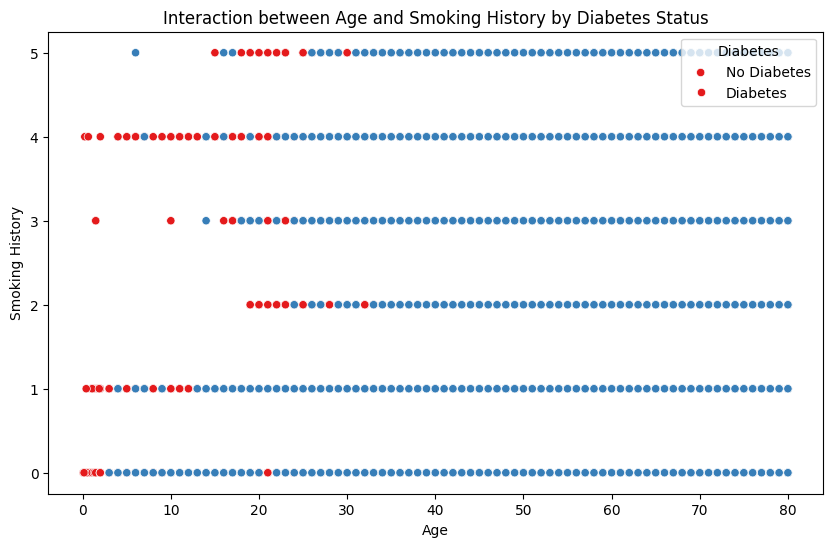

In [27]:
#interaction between smoking and age

#invert dict smoking
# inverse_smoking_map={v:k for k,v in smoking_map.items()} #invert dictionary to get back original values
# df4=df3.copy()
# df4['smoking_history']=df4['smoking_history'].map(inverse_smoking_map)
# # smoking_map={
# #     'No Info': 0,
# #     'never': 1,
# #     'former': 2,
# #     'current': 3,
# #     'not current': 4,
# #     'ever': 5
# # }

plt.figure(figsize=(10,6))
sns.scatterplot(x='age', y='smoking_history', hue='diabetes', data=df3, palette='Set1')
plt.title('Interaction between Age and Smoking History by Diabetes Status')
plt.xlabel('Age')
plt.ylabel('Smoking History')
plt.legend(title='Diabetes', labels=['No Diabetes', 'Diabetes'],loc='upper right')
plt.show()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Library/Frameworks/Python.framework/Versions/3.13/lib/p

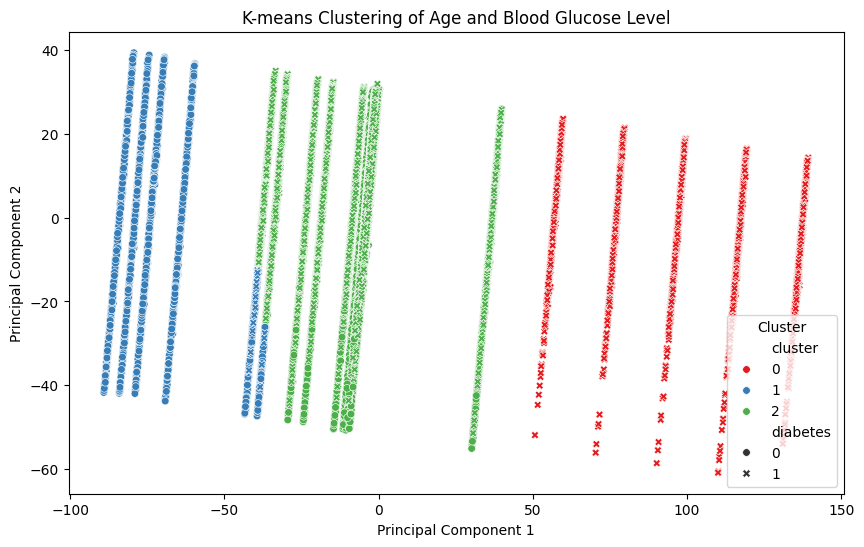

In [28]:
#k-means clustering for all factors and diabetes
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=3, random_state=0)

Y=df3['diabetes']
X=df3.drop(['diabetes','age_group'], axis=1)


kmeans.fit(X)
df3['cluster']=kmeans.labels_
df3.head()


#PCA -principal component analysis for dimensionality reduction
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X)
df3['pca1']=X_pca[:,0]
df3['pca2']=X_pca[:,1]

#visualise clusters
plt.figure(figsize=(10,6))
#shape by diabetes status and color by cluster
sns.scatterplot(x='pca1', y='pca2', hue='cluster', style='diabetes', data=df3, palette='Set1', markers=['o','X'], s=30)

plt.title('K-means Clustering of Age and Blood Glucose Level')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()



In [29]:
patients_prone=df3.query("cluster==2")
patients_prone.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,age_group,cluster,pca1,pca2
67423,1,49.0,0,0,3,24.36,6.5,200,0,31-50,2,35.967203,-6.282259
313,0,6.0,0,0,0,27.32,6.2,155,0,0-30,2,-13.575210,-43.350147
93199,1,14.0,0,0,0,21.37,6.2,145,0,0-30,2,-22.742965,-34.801221
49914,1,40.0,0,0,1,27.32,6.5,160,0,31-50,2,-4.714380,-10.288183
26182,1,31.0,0,0,4,20.10,4.0,130,0,31-50,2,-35.732897,-16.335353


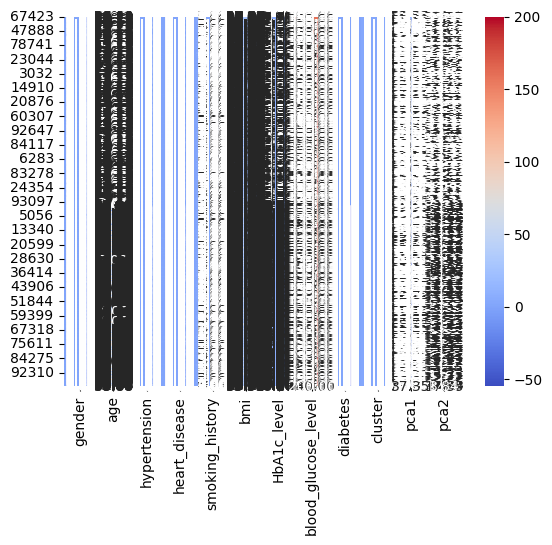

In [30]:
z=patients_prone.drop('age_group', axis=1)
sns.heatmap(z, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()